# Исследование заведений общественного питания в Москве

Автор: Казанцев Павел Павлович

## Цель и задачи  

**Цель:** Провести исследовательский анализ заведений общественного питания Москвы. Определить ключевые характеристики и факторы, влияющие на рейтинг.  

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить категории, районы, сетевость, количество мест, рейтинги;
    - изучить взаимосвязи данных с рейтингом.
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа поступили данные с заведениями общественного питания Москвы, составленные на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`

- `id` - идентификатор заведения;
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`

- `id` - идентификатор заведения;
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
       и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции.

In [1]:
!pip install phik -U 


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Загружаем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные rest_info_df и rest_price_df
rest_info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8405 строк, в которых представлена информация об заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов обозначены корректно.
- Представленные данные `id`, `name`, `category`, `address`, `district`, `hours` хранятся в типе `object`. Числовые столбцы `rating` и `seats` хранятся во `float64`. Также есть бинарный столбец `chain` со значениями 0 и 1, которому понизить разрядность типа `int`.

    Столбец `category` можно перевести в соответствующий тип `category`.

    Столбец `seats` показывает кол-во мест в заведении и является дискретной величиной, из-за пропусков он в формате `float64`.

- Пропуски содержатся только в столбцах `rating` и `seats`. Однако следует проверить и другие столбцы: например `chain`, так как в документации указано, что могут встречаться ошибки.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4057 строк, в которых представлена информация о среднем чеке заведения. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов обозначены корректно.
- Типы данных соответствуют содержимому. Cтолбец `price` можно перевести в `category`.

    Столбцы `middle_avg_bill` и `middle_coffee_cup` заполняются на основе `avg_bill`
- Пропусков нет только в столбце `id`. Остальные столбцы достаточно плохо заполнены. В `middle_coffee_cup` например, отсутсвует больше 75%.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные имеют пропуски, особенно датасет `rest_price.csv` — пропуски встречаются в 4 из 5 столбцов; в `rest_info.csv` пропуски в 2 из 9 столбцов. Типы данных в датасетах обозначены верно, стоит лишь оптимизировать разрядность в нескольких столбцах. Сами столбцы корректно отображают суть данных.

In [8]:
# Cоединим два датафрейма в один
rest_df = rest_info_df.merge(rest_price_df, on='id', how='left')

In [9]:
# Проверим размерность датафрейма после присоденения 
rest_df.shape

(8406, 13)


---

## 2. Предобработка данных

### 2.1 Оптимизация типов данных

Так как названия столбцов указаны верно, перейдем сразу к оптимизации типов данных.

Уменьшим раздряность столбца `chain`:

In [10]:
# Оптимизируем целочисленный тип данных c помощью метода to_numeric и параметра downcast='integer'
rest_df['chain'] = pd.to_numeric(rest_df['chain'], downcast='integer')

Переведем столбцы `price` и `category` в тип `category`:

In [11]:
# Переводим тип в category с помощью метода astype
rest_df['category'] = rest_df['category'].astype('category')
rest_df['price'] = rest_df['price'].astype('category')

Оптимизируем разрядность типов float

In [12]:
for col in ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']:
    rest_df[col] = pd.to_numeric(rest_df[col], downcast='float', errors='coerce')
    print(rest_df[col].dtypes) 

float32
float32
float32
float32


Теперь проверим типы данных в обоих датафреймах:

In [13]:
rest_df.dtypes

id                     object
name                   object
category             category
address                object
district               object
hours                  object
rating                float32
chain                    int8
seats                 float32
price                category
avg_bill               object
middle_avg_bill       float32
middle_coffee_cup     float32
dtype: object

Оптимизация типов данных успешно завершена.

---

### 2.2 Проверка на наличие пропусков

При первичном анализе мы обнаружили, что пропуски встречаются в обоих датасетах.

Узнаем абсолютные и относительные значения в объединенном датасете `rest_df`:

In [14]:
# Применяем метод isna() к датафрейму rest_df
rest_df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [15]:
# Подсчитываем долю строк с пропусками
rest_df.isna().sum() / rest_df.shape[0] * 100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

В датафрейме `rest_df` обнаружено:

- 536 пропусков в столбце `hours` - **6,37%**
- 3611 пропусков в столбце `seats` - **42,92%**
- 5091 пропуск в столбце `price` - **60,56%**
- 4590 пропусков в столбце `avg_bill` - **54,60%**
- 5257 пропусков в столбце `middle_avg_bill` - **62,5%**
- 7871 пропуск в столбце `middle_coffee_cup` - **93,6%**

Напишем функцию, которая будет показывать кол-во и долю пропусков значений столбца в других столбцах:

In [16]:
def scan_missing(groupby, agg):
    scan = rest_df.groupby(groupby).agg(
        missing_count=(agg, lambda x: x.isna().sum()),
        missing_percent=(agg, lambda x: x.isna().mean() * 100)
    ).sort_values(by='missing_percent', ascending=False)
    return scan

Посмотрим как распределяются пропуски `hours` в категориальных столбцах через цикл:

In [17]:
for col in ['category', 'district', 'chain', 'price']:
    print(f'Распределение пропусков в {col}:')
    display(scan_missing(groupby=col, agg ='hours'))

Распределение пропусков в category:


C:\Users\Pavel\AppData\Local\Temp\ipykernel_7692\883979140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scan = rest_df.groupby(groupby).agg(


,missing_count,missing_percent
category,,
кафе,375,15.769554
быстрое питание,33,5.472637
ресторан,74,3.622124
столовая,9,2.857143
булочная,7,2.734375
"бар,паб",18,2.352941
кофейня,15,1.061571
пиццерия,5,0.789889


Распределение пропусков в district:


,missing_count,missing_percent
district,,
Юго-Восточный административный округ,85,11.904762
Северо-Западный административный округ,40,9.779951
Восточный административный округ,75,9.398496
Юго-Западный административный округ,59,8.321580
Западный административный округ,66,7.755582
Южный административный округ,65,7.286996
Северо-Восточный административный округ,61,6.846240
Северный административный округ,54,6.000000
Центральный административный округ,31,1.382694


Распределение пропусков в chain:


,missing_count,missing_percent
chain,,
0,420,8.075370
1,116,3.619345


Распределение пропусков в price:


C:\Users\Pavel\AppData\Local\Temp\ipykernel_7692\883979140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scan = rest_df.groupby(groupby).agg(


,missing_count,missing_percent
price,,
средние,5,0.236183
высокие,0,0.000000
выше среднего,0,0.000000
низкие,0,0.000000


Можем заметить, что большинство пропусков в часах работы есть у категории заведений "Кафе" и они являются не сетевыми (chain - 0).

Можно предположить, что эти заведения недавно открылись и еще не успели проставить часы работы или часы работы постоянно меняются. Скорее всего эти пропуски природы MAR.

В столбце `seats` слишком много пропусков, чтобы удалаять их (потеряем ~42,92% данных).

Для начала проверм распределение пропусков по данным через созданную функцию `scan_missing`:

In [18]:
for col in ['category', 'district', 'chain', 'price']:
    print(f'Распределение пропусков в {col}:')
    display(scan_missing(groupby=col, agg='seats'))

Распределение пропусков в category:


C:\Users\Pavel\AppData\Local\Temp\ipykernel_7692\883979140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scan = rest_df.groupby(groupby).agg(


,missing_count,missing_percent
category,,
кафе,1160,48.780488
столовая,151,47.936508
кофейня,662,46.850672
булочная,108,42.187500
быстрое питание,254,42.122720
"бар,паб",297,38.823529
ресторан,773,37.836515
пиццерия,206,32.543444


Распределение пропусков в district:


,missing_count,missing_percent
district,,
Юго-Восточный административный округ,364,50.980392
Восточный административный округ,380,47.619048
Центральный административный округ,1064,47.457627
Западный административный округ,373,43.830787
Северо-Восточный административный округ,386,43.322110
Юго-Западный административный округ,261,36.812412
Южный административный округ,325,36.434978
Северный административный округ,315,35.000000
Северо-Западный административный округ,143,34.963325


Распределение пропусков в chain:


,missing_count,missing_percent
chain,,
0,2333,44.856758
1,1278,39.875195


Распределение пропусков в price:


C:\Users\Pavel\AppData\Local\Temp\ipykernel_7692\883979140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scan = rest_df.groupby(groupby).agg(


,missing_count,missing_percent
price,,
средние,841,39.726027
низкие,59,37.820513
выше среднего,207,36.702128
высокие,158,33.054393


Пропуски в количестве мест особенно характерны для кафе, столовых и кофеен. Это может быть связано с тем, что для многих небольших заведений (особенно кафе) информация о вместимости не является важной, так как не требует бронирования места, в отличие от ресторана, где пропусков меньше (предположительно MNAR).

Сейчас мы не будем заполнять 42,9% пропусков индикаторами или расчетным значением, чтобы не испортить статистику. Но создадим отдельный столбец, который будет отображать наличие пропусков.

 Создадим для пропусков отдельный столбец `seats_missing`, который будет показывать 1 - пропуск есть, 0 - пропуска нет

In [19]:
rest_df['seats_missing'] = rest_df['seats'].isna().astype(int)

Теперь проверим пропуски в столбце `price`, конкретно взаимосвязь пропусков с другими столбцами:

In [20]:
# Посмотрим на распределение пропусков через цикл и ранее созданную функцию scan_missing
for col in ['category', 'district', 'chain']:
    print(f'Распределение пропусков в {col}:')
    display(scan_missing(groupby=col, agg='price'))

Распределение пропусков в category:


C:\Users\Pavel\AppData\Local\Temp\ipykernel_7692\883979140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scan = rest_df.groupby(groupby).agg(


,missing_count,missing_percent
category,,
булочная,215,83.984375
кафе,1745,73.380992
быстрое питание,413,68.490879
кофейня,937,66.312810
столовая,162,51.428571
пиццерия,322,50.868878
ресторан,1026,50.220264
"бар,паб",271,35.424837


Распределение пропусков в district:


,missing_count,missing_percent
district,,
Юго-Восточный административный округ,515,72.128852
Восточный административный округ,554,69.423559
Юго-Западный административный округ,464,65.444288
Северо-Восточный административный округ,582,65.319865
Южный административный округ,581,65.134529
Северо-Западный административный округ,263,64.303178
Западный административный округ,544,63.924794
Северный административный округ,557,61.888889
Центральный административный округ,1031,45.985727


Распределение пропусков в chain:


,missing_count,missing_percent
chain,,
1,2068,64.524181
0,3023,58.123438


Можно предположить, что заведения сознательно скрывают ценовой уровень, чтобы не отпугивать клиентов. Особенно это касается булочных и кафе в спальных районах – там цены могут быть ниже, и владельцы боятся, что клиенты подумают о низком качестве. Предполагаемый тип пропусков - MNAR, так как пропуски связаны с самой ценой

Так как пропусков много, мы не будем заполнять их расчетным значением или индикатором, чтобы не испортить распределение, так как можем занизить или завысить ценовую категорию в сегменте.

Создадим новый столбец на основе `price` - `price_segment`, где пропуски заполним осмысленными значениями `Не указан`:

In [21]:
rest_df['price_segment'] = rest_df['price'].astype('object').fillna('Не указан')

Теперь проверим пропуски в столбце `avg_bill`, конкретно взаимосвязь пропусков с другими столбцами:

In [22]:
for col in ['category', 'district', 'chain', 'price_segment']:
    print(f'Распределение пропусков в {col}:')
    display(scan_missing(groupby=col, agg='avg_bill'))

Распределение пропусков в category:


C:\Users\Pavel\AppData\Local\Temp\ipykernel_7692\883979140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scan = rest_df.groupby(groupby).agg(


,missing_count,missing_percent
category,,
булочная,203,79.296875
кафе,1680,70.647603
быстрое питание,365,60.530680
ресторан,1003,49.094469
кофейня,692,48.973815
столовая,134,42.539683
пиццерия,233,36.808847
"бар,паб",280,36.601307


Распределение пропусков в district:


,missing_count,missing_percent
district,,
Юго-Восточный административный округ,478,66.946779
Восточный административный округ,488,61.152882
Юго-Западный административный округ,433,61.071932
Северо-Восточный административный округ,523,58.698092
Южный административный округ,518,58.071749
Западный административный округ,489,57.461810
Северо-Западный административный округ,224,54.767726
Северный административный округ,487,54.111111
Центральный административный округ,950,42.372881


Распределение пропусков в chain:


,missing_count,missing_percent
chain,,
0,2850,54.797154
1,1740,54.290172


Распределение пропусков в price_segment:


,missing_count,missing_percent
price_segment,,
Не указан,4348,85.405618
средние,173,8.171941
выше среднего,40,7.092199
высокие,23,4.811715
низкие,6,3.846154


Те же причины, что и для `price` – заведения не хотят раскрывать информацию о среднем чеке, чтобы не влиять на выбор клиентов. Часто это единая стратегия: если скрывают ценовую категорию, то и средний чек тоже не публикуют.


Создадим отдельный столбец `avg_bill_segment`, где заполним пропуски значениями `Не указан`

In [23]:
rest_df['avg_bill_segment'] = rest_df['avg_bill'].fillna('Не указан')

Теперь обработаем значения `avg_bill_segment` для заполнения столбца `middle_avg_bill` с помощью пользовательской функции `extract_middle_avg_bill`:

In [24]:
#Добавим библиотеку для работы с регулярными выражениями и указанием nan значений
import re
import numpy as np

In [25]:

def extract_middle_avg_bill(avg_bill_text):
    """
    Извлекает числовое значение среднего чека из строки.
    Если строка не начинается с 'Средний счёт' или не содержит чисел,
    возвращает NaN.
    
    Параметры:
        avg_bill_text (str): значение из столбца avg_bill_segment (тип object)
    
    Возвращает:
        float: вычисленное значение (медиана диапазона, одно число или 0)
    """
    # Если значение avg_bill_segment хранит 'Не указан' возращаем 0.0
    if avg_bill_text == 'Не указан':
        return np.nan
    
    # Проверка начала
    if not str(avg_bill_text).startswith('Средний счёт'):
        return np.nan
    
    # Извлекаем все числа
    numbers = re.findall(r'\d+', str(avg_bill_text))

    # Если чисел нет — возвращаем 0
    if not numbers:
        return np.nan

    # Преобразуем в целые числа
    numbers = list(map(int, numbers))

    # Если одно число — возвращаем его
    if len(numbers) == 1:
        return float(numbers[0])

    # Если два и более — берём первые два как диапазон и возвращаем их среднее
    return (numbers[0] + numbers[1]) / 2.0
    

In [26]:
rest_df['middle_avg_bill'] = rest_df['avg_bill_segment'].apply(extract_middle_avg_bill)

In [27]:
# Убедимся, что для "Не указан" возвращается nan
sample = rest_df[rest_df['avg_bill_segment'] == 'Не указан'].head(5)
print(sample[['avg_bill_segment', 'middle_avg_bill']])

# Проверим, что для "Средний счёт" извлекаются числа
sample2 = rest_df[rest_df['avg_bill_segment'].str.startswith('Средний счёт', na=False)].head(5)
print(sample2[['avg_bill_segment', 'middle_avg_bill']])

# Посмотрим распределение значений (сколько nan, сколько чисел)
print(rest_df['middle_avg_bill'].value_counts(dropna=False).head(10))

   avg_bill_segment  middle_avg_bill
0         Не указан              NaN
5         Не указан              NaN
11        Не указан              NaN
13        Не указан              NaN
19        Не указан              NaN
           avg_bill_segment  middle_avg_bill
1  Средний счёт:1500–1600 ₽           1550.0
2    Средний счёт:от 1000 ₽           1000.0
4    Средний счёт:400–600 ₽            500.0
6        Средний счёт:199 ₽            199.0
7    Средний счёт:200–300 ₽            250.0
middle_avg_bill
NaN       5257
1250.0     247
1000.0     174
300.0      148
1500.0     146
400.0      134
1750.0     130
500.0      126
750.0      100
2000.0      95
Name: count, dtype: int64


Мы успешно заполнили столбец `middle_avg_bill` по условиям:
- для ценового диапазона из двух чисел мы взяли медиану;
- если в строке было всего одно число - заполнили пропуски им;
- Если строка не начиналась со "Средний счет" или была заполнена значением "Не указан" заполнили значением NaN, чтобы в дальнейшем не исказить статастики

Таким же образом заполним столбец `middle_coffee_cup` с помощью столбца `avg_bill_segment` и пользователской функции `extract_middle_coffee_cup`:


In [28]:
def extract_middle_coffee_cup(avg_bill_text):
    """
    Извлекает числовое значение цены чашки капучино из строки.
    
    Функция анализирует текст из столбца avg_bill_segment. Если строка 
    начинается с подстроки 'Цена одной чашки капучино', то из неё 
    извлекаются все числа (цифровые последовательности). Далее:
      - Если найдено одно число — возвращается оно как float.
      - Если найдено два числа — возвращается их среднее арифметическое 
        (медиана диапазона).
      - Если чисел нет или они не найдены — возвращается np.nan.
    
    Для всех остальных случаев (строка не начинается с указанной подстроки, 
    строка равна 'Не указан', или значение не является строкой) также 
    возвращается np.nan.

    Параметры:
        avg_bill_text (str или любой тип): значение из столбца avg_bill_segment.
    """
    # Если значение avg_bill_segment хранит 'Не указан' возращаем np.nan
    if avg_bill_text == 'Не указан':
        return np.nan

    # Если значение не типа строка - возвращаем 0.0:
    if not isinstance(avg_bill_text, str):
        return np.nan

    # Проверка начала
    if not str(avg_bill_text).startswith('Цена чашки капучино'):
        return np.nan

    # Извлекаем числа из текста
    numbers = re.findall(r'\d+', str(avg_bill_text)) 

    # Если чисел нет — возвращаем 0
    if not numbers:
        return np.nan

    # Преобразуем числа в int
    numbers = list(map(int, numbers))

    # Если одно число в списке - возвращаем его
    if len(numbers) == 1:
        return float(numbers[0])

    # Если числе два - возвращаем их медиану
    return (numbers[0] + numbers[1]) / 2.0


In [29]:
rest_df['middle_coffee_cup'] = rest_df['avg_bill_segment'].apply(extract_middle_coffee_cup)

In [30]:
# Убедимся, что для "Не указан" возвращается nan
sample = rest_df[rest_df['avg_bill_segment'] == 'Не указан'].head(5)
print(sample[['avg_bill_segment', 'middle_coffee_cup']])

# Проверим, что для "Средний счёт" извлекаются числа
sample2 = rest_df[rest_df['avg_bill_segment'].str.startswith('Цена чашки капучино', na=False)].head(5)
print(sample2[['avg_bill_segment', 'middle_coffee_cup']])

# Посмотрим распределение значений (сколько nan, сколько чисел)
print(rest_df['middle_coffee_cup'].value_counts(dropna=False).head(10))

   avg_bill_segment  middle_coffee_cup
0         Не указан                NaN
5         Не указан                NaN
11        Не указан                NaN
13        Не указан                NaN
19        Не указан                NaN
                  avg_bill_segment  middle_coffee_cup
3    Цена чашки капучино:155–185 ₽              170.0
72   Цена чашки капучино:150–190 ₽              170.0
81   Цена чашки капучино:120–170 ₽              145.0
89   Цена чашки капучино:100–200 ₽              150.0
100  Цена чашки капучино:150–210 ₽              180.0
middle_coffee_cup
NaN      7871
256.5      43
60.0       33
95.0       32
150.0      24
170.0      18
200.0      18
250.0      15
225.0      15
135.0      14
Name: count, dtype: int64


Мы успешно заполнили столбец `middle_avg_bill` по условиям:
- для ценового диапазона из двух чисел мы взяли медиану;
- если в строке было всего одно число - заполнили пропуски им;
- Если строка не начиналась со "Цена чашки капучино" или была заполнена значением "Не указан" заполнили значением NaN, чтобы в дальнейшем не исказить статастики

In [31]:
# Вернем значения во float32
for col in ['middle_coffee_cup', 'middle_avg_bill']:
    rest_df[col] = pd.to_numeric(rest_df[col], downcast='float')
    print(col, rest_df[col].dtype)

middle_coffee_cup float32
middle_avg_bill float32


In [32]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   category
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float32 
 7   chain              8406 non-null   int8    
 8   seats              4795 non-null   float32 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float32 
 12  middle_coffee_cup  535 non-null    float32 
 13  seats_missing      8406 non-null   int64   
 14  price_segment      8406 non-null   object  
 15  avg_bill_segment   8406 non-null   object  
dtypes: cat

Далее проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Иногда для анализа поступают уже частично или полностью подготовленные данные. Если аналитик не знает, по какому алгоритму происходили первичный сбор и обработка данных, лучше дополнительно проверить, использовались ли значения-индикаторы для замены пропусков. Это поможет понять качество данных и избежать ошибок при их агрегации, когда значение-индикатор будет учитываться при расчёте среднего или медианы, что исказит исходные данные.

Посмотрим на уникальные значения в ключевых данных — среди них категория заведения, район, признак сетевости, ценовая категория заведения.

In [33]:
# Проверяем уникальные значения в столбцах
for column in ['category', 'district', 'chain', 'price_segment']:
    print(f'Уникальные значения в столбце {column}:')
    print(rest_df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']
Categories (8, object): ['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце chain:
[0 1]

Уникальные значения в столбце price_segment:
['Не указан' 'высокие' 'выше среднего' 'низкие' 'средние']



Все значения выглядят корректными. Теперь можно перейти к изучению дубликатов в данных.

---

### 2.3. Проверка на явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [25]:
rest_df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` заведений, то есть каждая строка в данных — уникальный заведение:

In [26]:
rest_df.duplicated(subset='id').sum()

np.int64(0)

In [27]:
# Приведем данные о названии и адресе заведения в нижний регистр
rest_df['name'] = rest_df['name'].str.lower()
rest_df['address'] = rest_df['address'].str.lower()

In [28]:
# Проверим наличие неявных дубликатов столбцов названия и адреса
rest_df.duplicated(subset=['name', 'address'], keep='first').sum()

np.int64(4)

In [29]:
#Удалим неявные дубликаты названия и адреса
rest_df.drop_duplicates(subset=['name', 'address'], keep='first', inplace=True)

Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
- логическое значение True — если заведение работает ежедневно и круглосуточно;
- логическое значение False — в противоположном случае.

In [30]:
def hour_24_7(row):
    if row == 'ежедневно, круглосуточно':
        return True
    return False

In [31]:
rest_df['is_24_7'] = rest_df['hours'].apply(hour_24_7)

Мы успешно обработали дубликаты, теперь можем перейти к промежуточным выводам по предобработке

---

## 2.5 Промежуточные выводы после предобработки

В ходе предобработки были выполнены следующие этапы:

1. **Объединение датасетов** – информация о заведениях (rest_info) и ценовых данных (rest_price) соединена по id.

2. **Оптимизация типов** – понижена разрядность числовых столбцов (chain → int8, rating, seats, middle_avg_bill, middle_coffee_cup → float32), категориальные признаки (category, price) переведены в тип category для экономии памяти.

3. **Обработка пропусков**:

    В `hours` (6.4%) – заполнены модой по группе (category, chain).

    В `seats` (42.9%) – пропуски оставлены, создан бинарный индикатор seats_missing.

    В `price` (60.6%) – создан новый столбец price_segment со значением 'Не указан' для пропусков, исходный столбец сохранён с NaN.

    В `avg_bill` (54.6%) – аналогично создан avg_bill_segment с 'Не указан'.

4. **Извлечение числовых значений** – разработаны функции для парсинга текстовых диапазонов из `avg_bill_segment`; столбцы `middle_avg_bill` и `middle_coffee_cup` перезаполнены: для «Средний счёт» и «Цена чашки капучино» вычислена медиана диапазона или взято одиночное число, для остальных случаев – NaN.

5. **Проверка и удаление дубликатов**:

Явных дубликатов строк не обнаружено.

Неявных дубликатов по id не найдено.

После приведения названий и адресов к нижнему регистру дубликатов по паре (name, address) обнаружено 4 неяв. дубликата (удалено).

6. **Контроль качества** – уникальные значения категориальных признаков корректны и единообразны.

**Ключевое решение**: для столбцов с большим процентом пропусков (`seats`, `price`, `avg_bill`) мы не заполняли их расчётными значениями, чтобы не искажать распределение и сохранить информацию о характере пропусков (предположительно MNAR – заведения намеренно скрывают ценовые данные). Вместо этого созданы отдельные категории `'Не указан'` и индикаторы пропусков.

## 3. Исследовательский анализ данных

### 3.1 Категории заведения в данных 

In [41]:
# Выведем все категории и кол-во в датасете
rest_df['category'].value_counts()

category
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

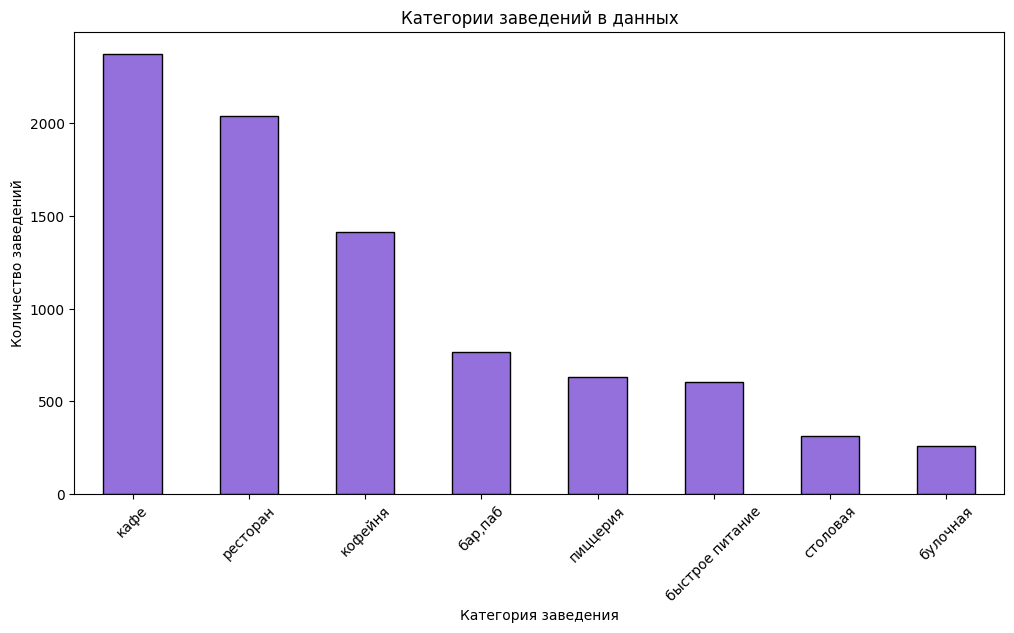

In [42]:
# Визуализирем распределение категорий по данным
rest_df['category'].value_counts().plot(
    kind='bar',
    figsize=(12, 6),
    title='Категории заведений в данных',
    xlabel='Категория заведения',
    ylabel='Количество заведений',
    color='mediumpurple',
    edgecolor='black',
    rot=45
)

plt.show()

Всего в данных представлено 8 видов заведений.

Преобладают из них: **кафе** (2376), **ресторан** (2042) и **кофейня** (1413)

### 3.2 Районы Москвы и распределения заведений по ним 

In [43]:
# Посмотрим какие районы представлены в данных
rest_df['district'].value_counts()

district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

В данных представлено 9 райнов Москвы, преобладает количеством заведений - **ЦАО** (2242)

<Axes: title={'center': 'Распределение заведений по районам Москвы'}, xlabel='Количество заведений', ylabel='Районы Москвы'>

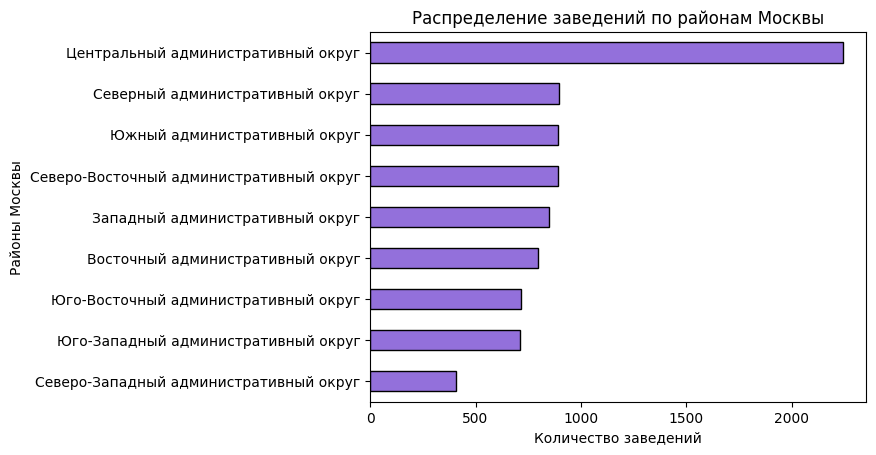

In [44]:
# Посмотрим как распределяются заведения по районам Москвы
rest_df['district'].value_counts().sort_values().plot(
    kind='barh',
    color='mediumpurple',
    edgecolor='black',
    xlabel='Количество заведений',
    ylabel='Районы Москвы',
    title='Распределение заведений по районам Москвы'
)

Посмотрим как распределяются заведения в самом распространенном районе Москвы - **ЦАО**

In [45]:
rest_df[rest_df['district'] == 'Центральный административный округ']['category'].value_counts().sort_values(
    ascending=False)

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64

<Axes: title={'center': 'Распределение заведений по ЦАО'}, xlabel='Количество заведений', ylabel='Категория заведения'>

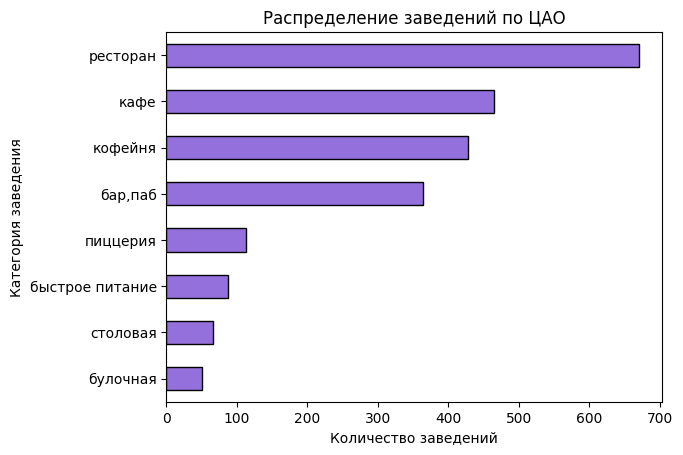

In [46]:
rest_df[rest_df['district'] == 'Центральный административный округ']['category'].value_counts().sort_values().plot(
    kind='barh',
    color='mediumpurple',
    edgecolor='black',
    xlabel='Количество заведений',
    ylabel='Категория заведения',
    title='Распределение заведений по ЦАО'
)

Внутри ЦАО самый распространненый вид заведения - **ресторан** (670);

Также есть большое количество кафе (464), кофеен (428), баров, пабов (364).

### 3.3 Соотношение сетевых и несетевых заведений

In [47]:
# Посмотрим как распределяются данные по сетевости
rest_df['chain'].value_counts(normalize=True) * 100

chain
0    61.878124
1    38.121876
Name: proportion, dtype: float64

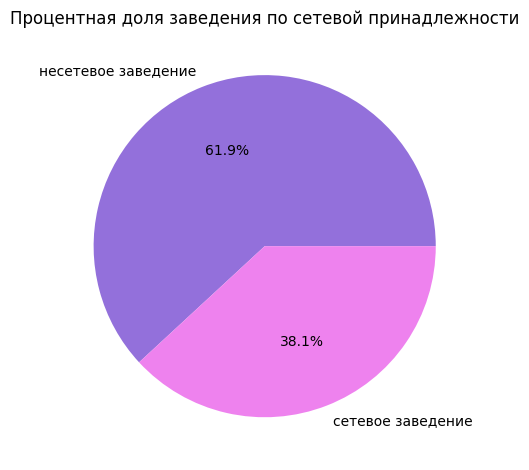

In [48]:
(rest_df['chain'].value_counts(normalize=True) * 100).rename(index={0: 'несетевое заведение', 1: 'сетевое заведение'}).plot(
    kind='pie',
    colors=['mediumpurple', 'violet'],
    autopct='%1.1f%%',
    legend=False,
    ylabel=''
)

plt.title('Процентная доля заведения по сетевой принадлежности')
plt.tight_layout()

В данных преобладают **несетевые** заведения (61,8% vs 38,12%)

In [49]:
# Посмотрим распределение доли сетевых заведений в разрезе их категории
(rest_df.groupby('category')['chain'].mean() * 100).sort_values(ascending=False)

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\412617375.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (rest_df.groupby('category')['chain'].mean() * 100).sort_values(ascending=False)


category
булочная           61.328125
пиццерия           52.132701
кофейня            50.955414
быстрое питание    38.474295
ресторан           35.700294
кафе               32.786195
столовая           27.936508
бар,паб            21.989529
Name: chain, dtype: float64

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\3965174343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = rest_df.groupby('category')['chain'].mean().sort_values(ascending=False)


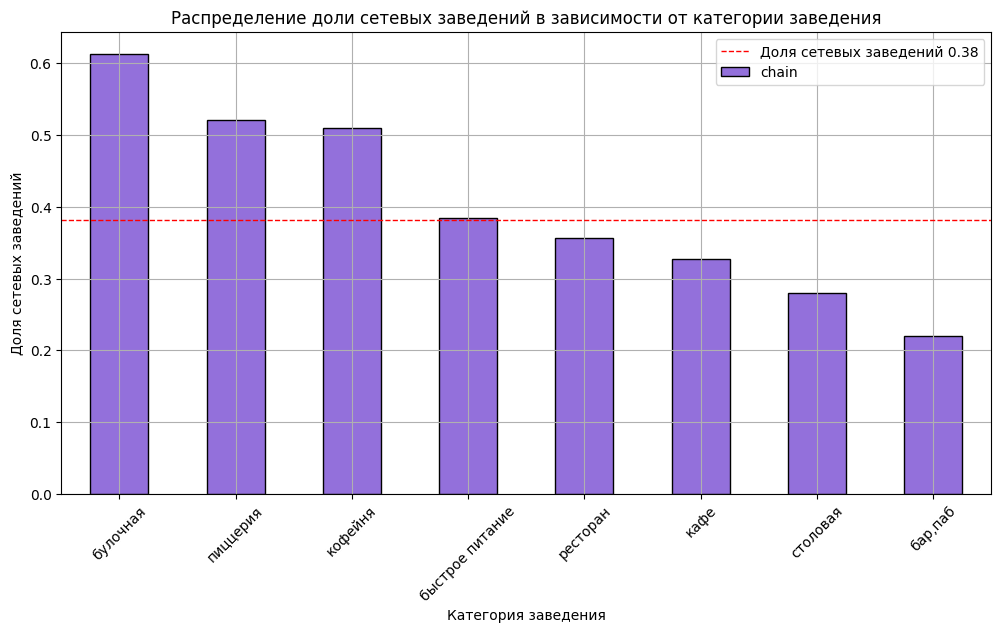

In [50]:
df_grouped = rest_df.groupby('category')['chain'].mean().sort_values(ascending=False)

df_grouped.plot(
    kind='bar',
    legend=True,
    color='mediumpurple',
    edgecolor='black',
    rot=45,
    xlabel='Категория заведения',
    ylabel='Доля сетевых заведений',
    title='Распределение доли сетевых заведений в зависимости от категории заведения',
    figsize=(12, 6)
)

mean_chain_share = rest_df['chain'].mean()

plt.axhline(
   mean_chain_share,
   color='red',
   linestyle='--',
   linewidth=1,
   label=f'Доля сетевых заведений {mean_chain_share:.2f}'
)

plt.grid()
plt.legend()

plt.show()

На графике можем увидеть, что больше всего явлются сетевыми:

1. **булочные** - 61.32% сетевых
2. **пиццерии** - 52.13% сетевых
3. **кофейни** - 50.95% сетевых

### 3.4 Количество посадочных мест в заведениях

In [51]:
print('Статистические показатели столбца seats:')
rest_df['seats'].describe()

Статистические показатели столбца seats:


count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

По показателям можно предположить, что распределение вряд ли "нормальное", так как есть заметная разница между средним и медианой. Также данные имеют широкий разброси от min до max. Присутствуют выбросы

Дополнительно проверим это и построим гистограмму и диаграмму размаха:

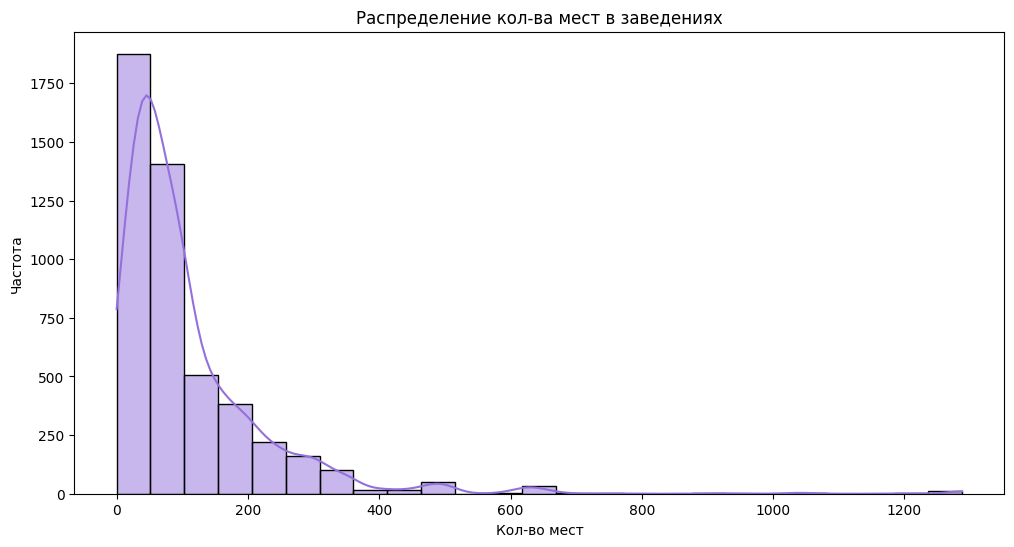

In [52]:
plt.figure(figsize = (12, 6))

sns.histplot(
    data=rest_df,
    x='seats',
    bins=25,
    color='mediumpurple',
    edgecolor='black',
    kde=True
)

plt.title('Распределение кол-ва мест в заведениях')
plt.xlabel('Кол-во мест')
plt.ylabel('Частота')

plt.show()

Text(0.5, 1.0, 'Распределение кол-ва мест в заведениях')

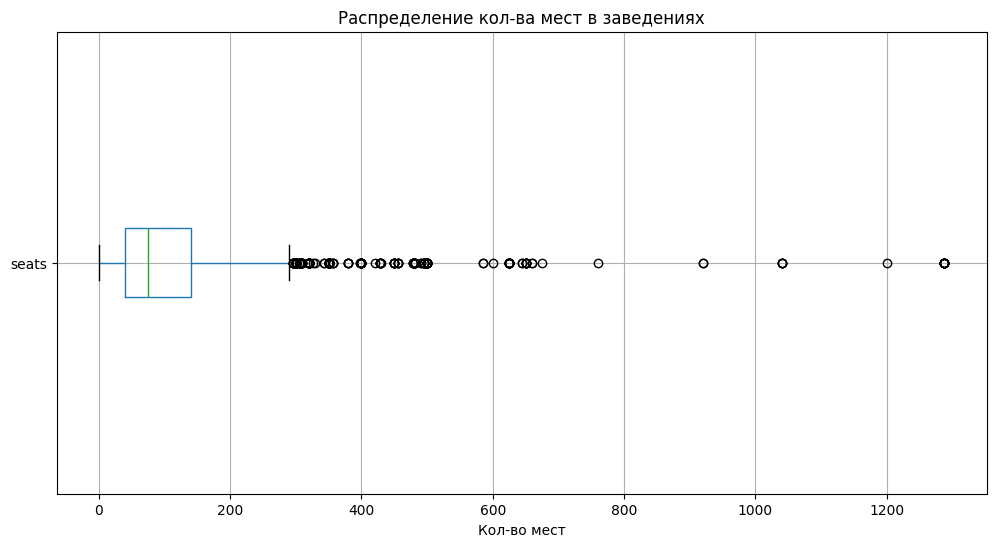

In [53]:
rest_df.boxplot(
    column='seats',
    vert=False,
    grid=True,
    figsize=(12, 6)
)

plt.xlabel('Кол-во мест')
plt.title('Распределение кол-ва мест в заведениях')

По гистограмме и диаграмме размаха можем убедиться, что распределение правоассиметричное, то есть значения смещены в правую положительную сторону. Основная масса значений находится в диапазоне от 0 до 300. После 300 идут возможные положительные выбросы

Посмотрим распределения мест для каждой категории заведения, ограниничив кол-во мест до 350

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\659867871.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data_sorted = plot_data.groupby('category')['seats'].median().sort_values(ascending=False).index.tolist()
C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\659867871.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


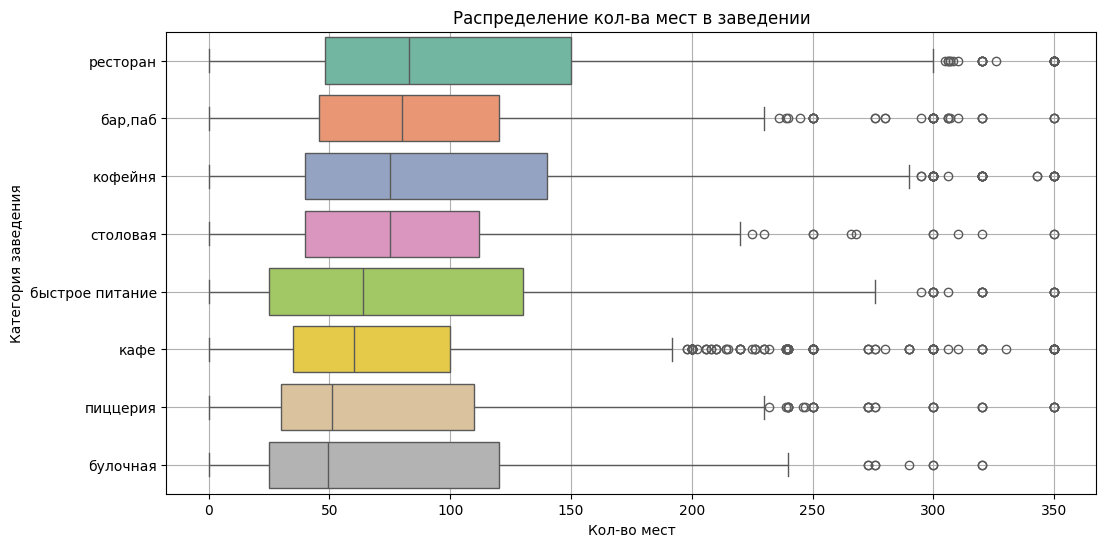

In [54]:
plt.figure(figsize =(12, 6))

plot_data = rest_df[rest_df['seats'] <= 350]

plot_data_sorted = plot_data.groupby('category')['seats'].median().sort_values(ascending=False).index.tolist()

sns.boxplot(
    data=plot_data,
    x='seats',
    y='category',
    order=plot_data_sorted,
    palette='Set2'
)

plt.grid()
plt.ylabel('Категория заведения')
plt.xlabel('Кол-во мест')
plt.title(f'Распределение кол-ва мест в заведении')
plt.show()

Графики распределения показывают, что практически у всех категорий заведений после значения в 200-300 посадочных мест начинаются выбросы.

Это может указывать, например, на фудкорты у заведений быстрого питания или на банкетные залы у ресторанов и столовых 

Также это может указывать на ошибки при заполнении данных.

In [55]:
# Изучим типичное кол-во мест для заведений
rest_df.groupby('category')[['seats']].median().sort_values(by='seats', ascending=False)

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\3757586309.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rest_df.groupby('category')[['seats']].median().sort_values(by='seats', ascending=False)


,seats
category,
ресторан,86.0
"бар,паб",82.0
кофейня,80.0
столовая,75.5
быстрое питание,65.0
кафе,60.0
пиццерия,55.0
булочная,50.0


Наибольшее кол-во мест у **ресторанов** - 86, наименьшее у **булочных** - 50, что соответсвует специфике заведения

### 3.5 Исследуем рейтинг заведений 

In [56]:
rest_df.groupby('category')['rating'].mean().sort_values(ascending=False)

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\1372774367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rest_df.groupby('category')['rating'].mean().sort_values(ascending=False)


category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290401
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124284
быстрое питание    4.050249
Name: rating, dtype: float32

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\2323621825.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rest_df.groupby('category')['rating'].mean().sort_values(ascending=False).plot(


<Axes: title={'center': 'Распределение рейтинга по категориям заведений'}, xlabel='Категория заведения', ylabel='Рейтинг'>

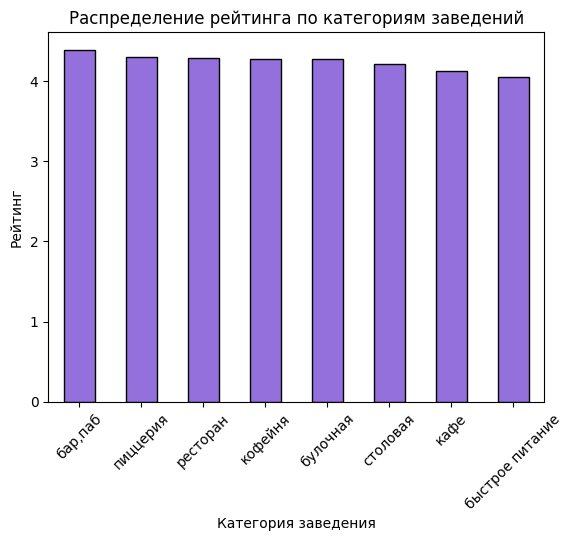

In [57]:
rest_df.groupby('category')['rating'].mean().sort_values(ascending=False).plot(
    kind='bar',
    xlabel='Категория заведения',
    ylabel='Рейтинг',
    title='Распределение рейтинга по категориям заведений',
    color='mediumpurple',
    edgecolor='black',
    rot=45
)

На графике видим, что существенного различия в рейтинге нет. Это означает что, в среднем, клиенты остаются довольны и плохой категории нет.

Рейтинг в разрезе категория держится в диапазоне от 4.05 до 4.38

### 3.6 Изучим корреляцию рейтинга заведений с другими данными

Построим матрицу корреляцию p_hik для изучения связи между рейтингом заведения и другими переменными (категорией заведения, райноном, сетевостью, кол-вом мест, временем работы):

In [58]:
corr_matrix = phik_matrix(rest_df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']])

corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']


,rating
price,0.262028
category,0.198752
district,0.189445
is_24_7,0.161010
chain,0.118857
seats,0.000000


<Axes: >

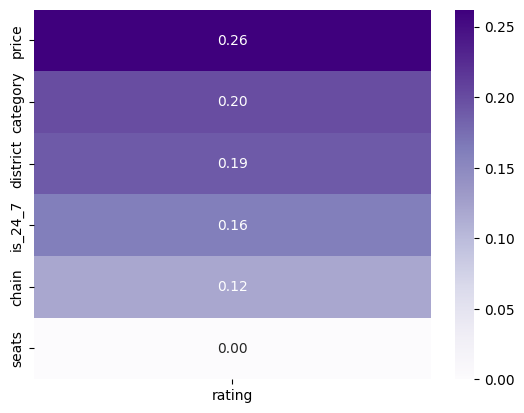

In [59]:
sns.heatmap(
    data=corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False),
    annot=True,
    fmt='.2f',
    cmap='Purples'
)

При первичном анализе корр. матрицы можем увидеть, что все исследуемые переменные имеют слабую положительную связь с рейтингом.

Так как мы построили корр. матрицу через универсальный p_hik метод, который может сравнивать категориальные, количественные и смешанные данные, он может быть обманчив.

Проверим корреляцию, построив подходящие графики для самых сильных связей:

In [60]:
# Напишем функцию для отображения графиков по разные переменные 
def plot_bar_plot(groupby, title, xlabel, rot=0, figsize=(10, 5)):
    group = rest_df.groupby(groupby)['rating'].mean().sort_values(ascending=False)
    group.plot(
        kind='bar',
        title=title,
        legend=True,
        color='mediumpurple',
        edgecolor='black',
        ylabel='Рейтинг',
        xlabel=xlabel,
        rot=rot,
        figsize=figsize)

    mean_rating_share = rest_df['rating'].mean()

    plt.axhline(
    mean_rating_share,
    color='red',
    linestyle='--',
    label = f'Cредний рейтинг по всем данным {mean_rating_share:.2f}'
    )
    
    plt.tight_layout()
    plt.grid()
    plt.legend()
    plt.show()

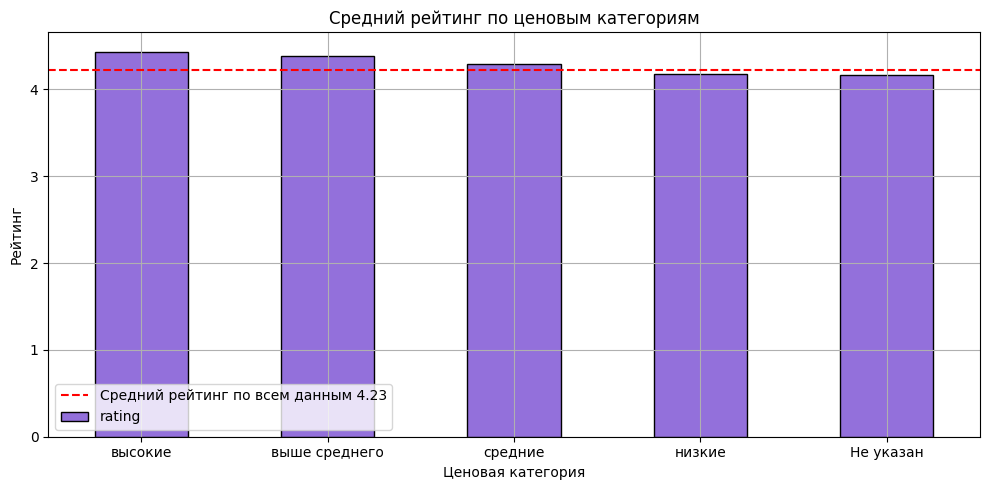

In [61]:
# Построим график для ценовой категории и рейтинга
title = 'Средний рейтинг по ценовым категориям'
xlabel = 'Ценовая категория'
plot_bar_plot('price_segment', title, xlabel)

На графике видим, что все ценовые категории заведений находятся близко к среднему рейтингу по данным. Однако заведениям с ценами выше среднего и высокими чаще ставят более высокие оценки.

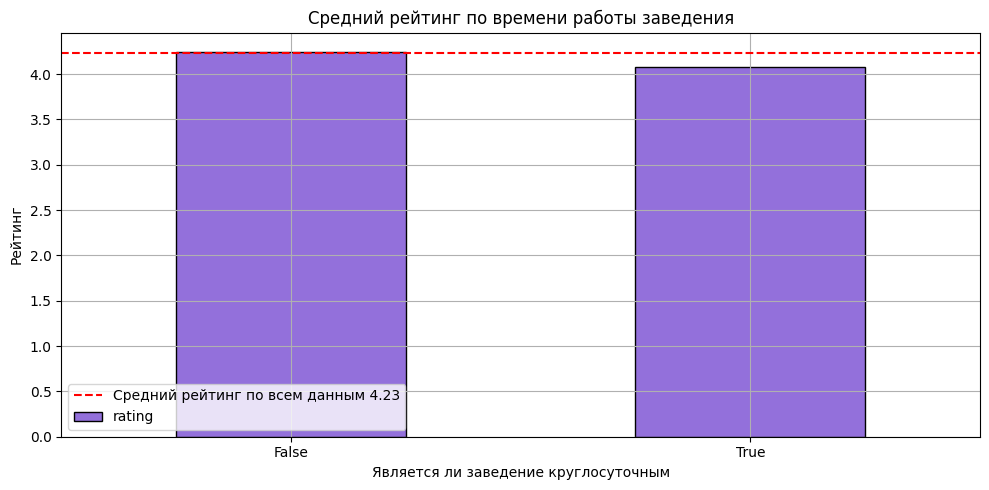

In [62]:
# Построим график для сравнения рейтинга по времени работы заведения
title = 'Средний рейтинг по времени работы заведения'
xlabel = 'Является ли заведение круглосуточным'
plot_bar_plot('is_24_7', title, xlabel)

Можем увидеть, что некруглосуточным заведениям ставят рейтинг выше.

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\1276945576.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = rest_df.groupby(groupby)['rating'].mean().sort_values(ascending=False)


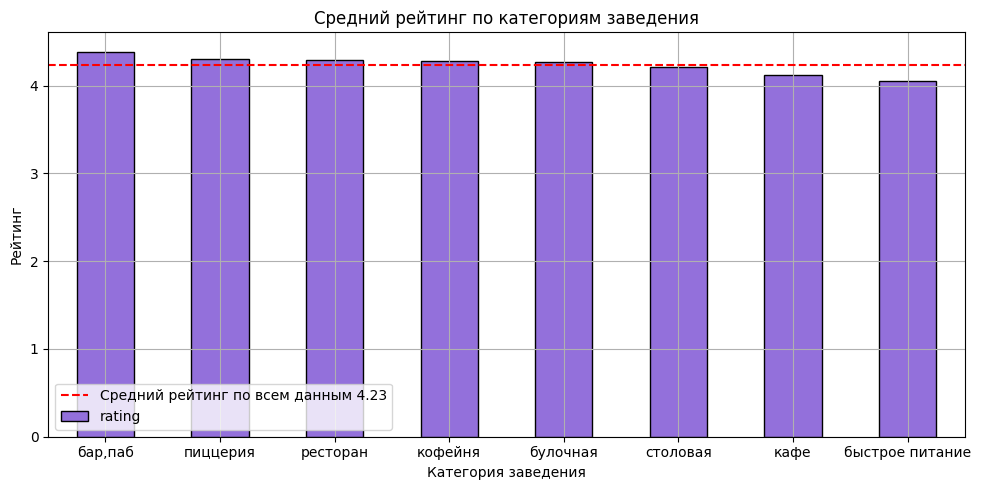

In [63]:
# Построим график для сравнения рейтинга по категориям заведения
title = 'Средний рейтинг по категориям заведения'
xlabel = 'Категория заведения'
plot_bar_plot('category', title, xlabel)

В среднем рейтинге с небольшим отрывом лидируют заведения "бар, паб", "пиццерия", "ресторан" и "кофейня"

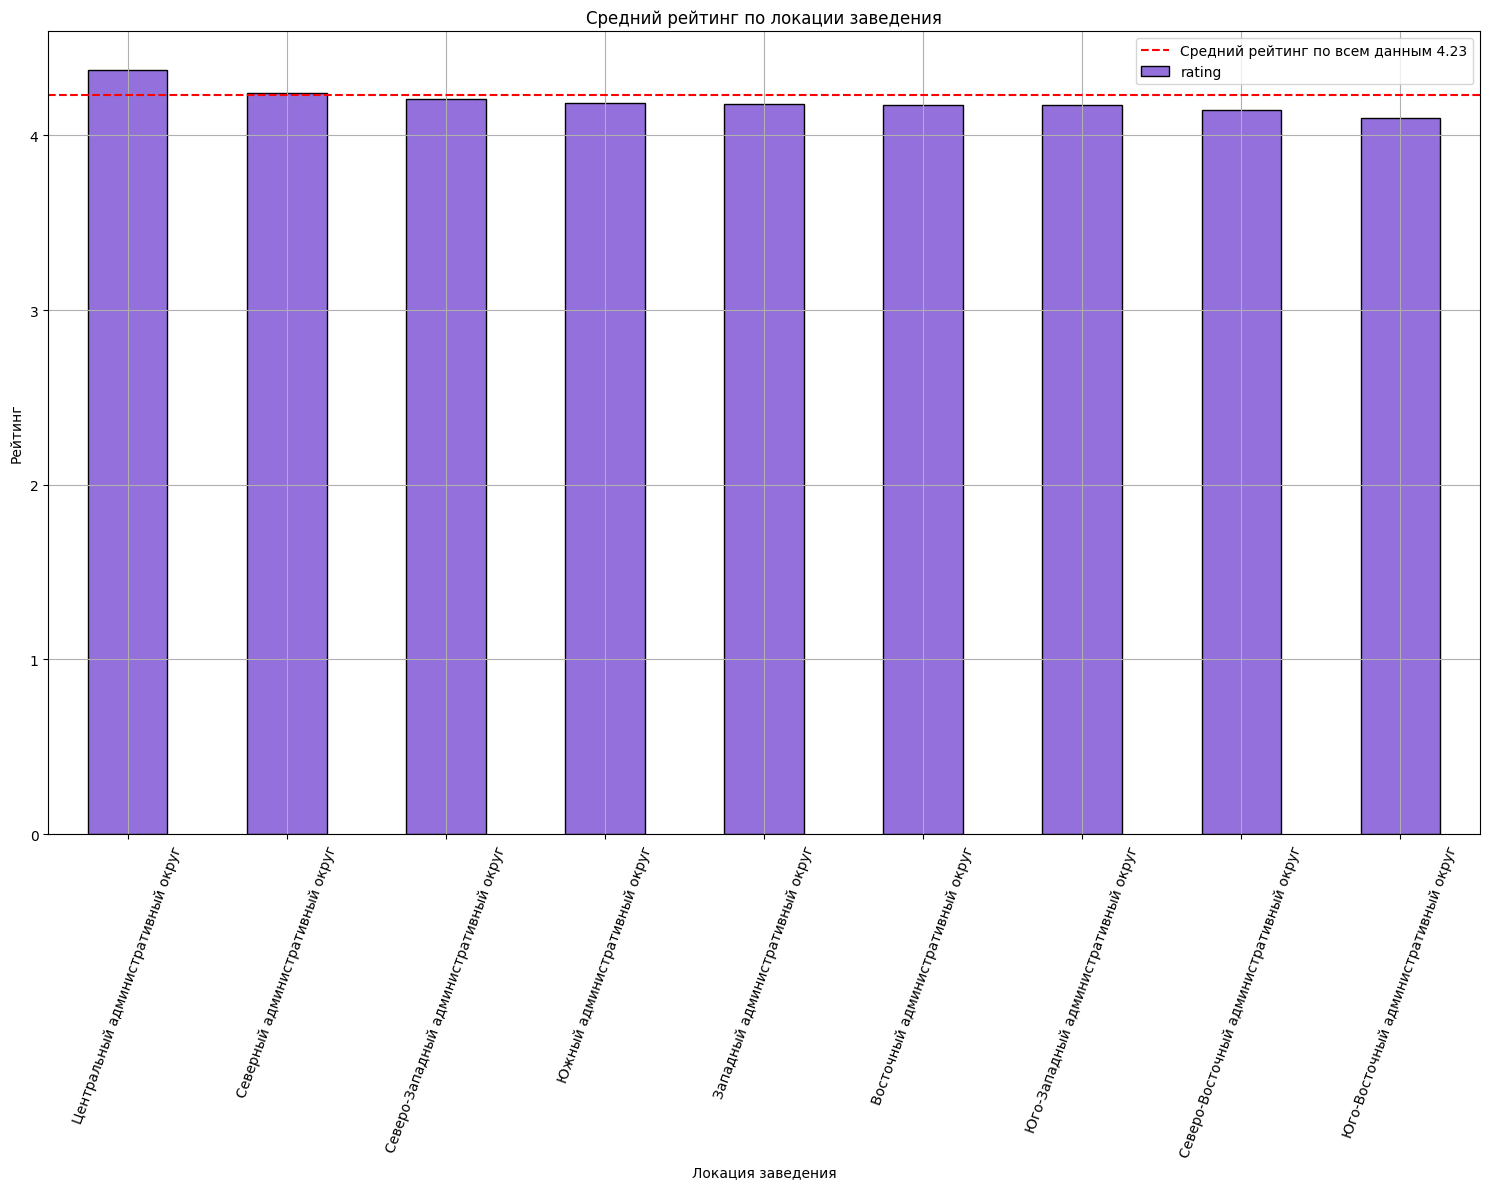

In [64]:
# Построим график для сравнения рейтинга по категориям заведения
title = 'Средний рейтинг по локации заведения'
xlabel = 'Локация заведения'
plot_bar_plot('district', title, xlabel, rot=70, figsize =(15, 12))

Также видим, что все районы держатся примерно близко по рейтингу. 

Однако Центральный административный округ среди всех оказывается выше

### 3.7 Изучим и найдем ТОП-15 популярных сетей в Москве

In [65]:
# Создадим отдельный датафрейм и укажем, что заведение должно быть сетевым
top = rest_df.loc[rest_df['chain'] == 1][['name', 'category', 'district']]

# Cоздадим датафрейм для рассчета среднего рейтинга по заведениям
top_mean_rating_per_name = rest_df.groupby('name')['rating'].mean().round(2).reset_index() 

# Посчитаем кол-во заведений для каждой сети
top_15 = top[['name']].value_counts().sort_values(ascending=False).head(15).reset_index()
top_15.columns = ['name', 'count']

# Соединим два датафрейма по названию заведения, исключая дубликаты
top_15 = top_15.merge(top.drop_duplicates(subset='name'), on='name', how='left')

# Соеденим датафрейм для добавления среднего рейтинга по заведения, исключая дубликаты
top_15 = top_15.merge(top_mean_rating_per_name.drop_duplicates(subset='name'), on='name', how='left')

top_15

,name,count,category,district,rating
0,шоколадница,120,кофейня,Северо-Восточный административный округ,4.18
1,домино'с пицца,76,пиццерия,Северный административный округ,4.17
2,додо пицца,74,пиццерия,Северный административный округ,4.29
3,one price coffee,71,кофейня,Северо-Восточный административный округ,4.07
4,яндекс лавка,69,ресторан,Северный административный округ,3.87
5,cofix,65,кофейня,Северный административный округ,4.08
6,prime,50,ресторан,Северо-Западный административный округ,4.12
7,хинкальная,44,быстрое питание,Северо-Восточный административный округ,4.32
8,кофепорт,42,кофейня,Северный административный округ,4.15
9,кулинарная лавка братьев караваевых,39,кафе,Северный административный округ,4.39


Среди 15 самых популярных заведений преобладают **кофейни**

Визуализируем данные:

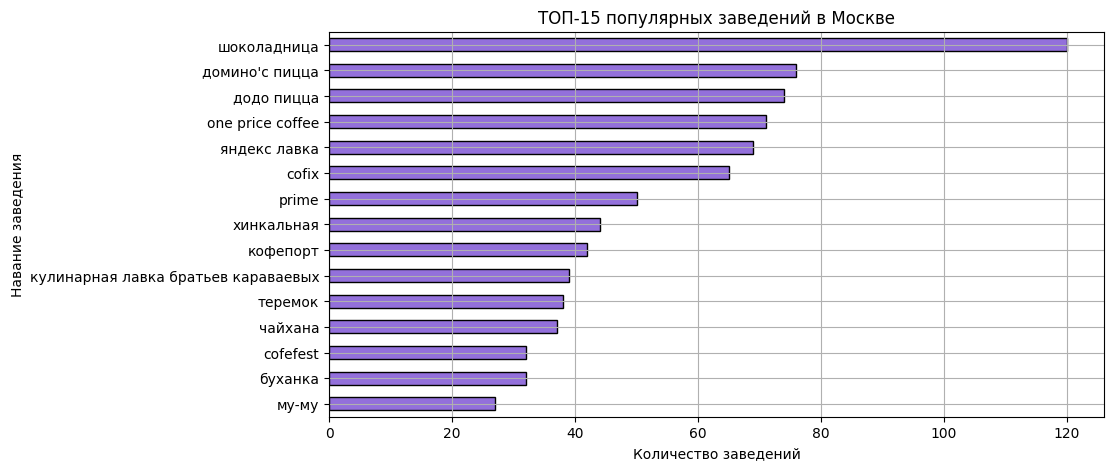

In [66]:
top_15.sort_values(by='count').plot(
    kind='barh',
    x='name',
    y='count',
    title='ТОП-15 популярных заведений в Москве',
    color='mediumpurple',
    edgecolor='black',
    legend=False,
    ylabel='Навание заведения',
    xlabel='Количество заведений',
    rot=0,
    figsize=(10, 5))
    
    
plt.grid()
plt.show()

Самым популярным заведением является "Шоколадница" - **120 точек кофейни**

Далее идет: "домино'с пицца" - **76 точек пиццерии**,
            "додо пицца" - **74 точек пиццерии**,
            "one price coffee" - **71 точка кофейни**

Построим визулизацию заведений по их среднему рейтингу:

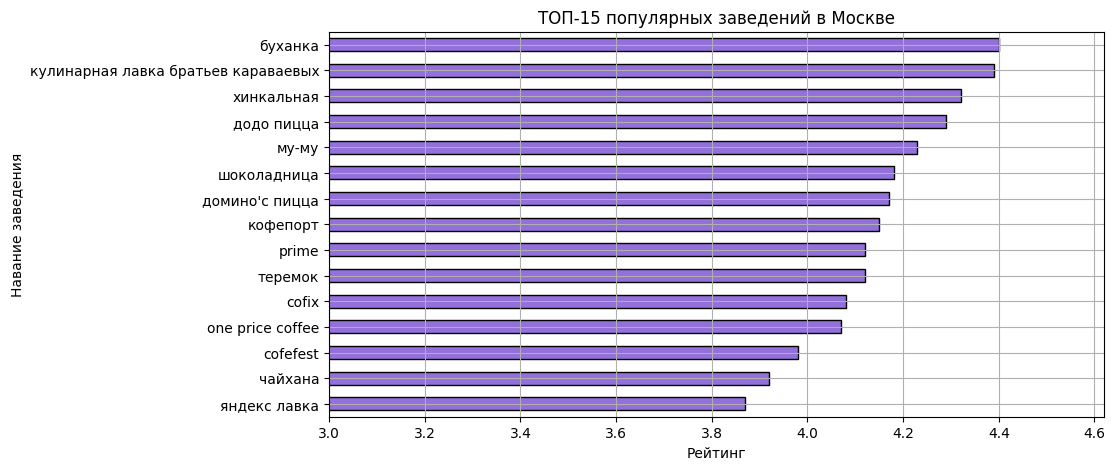

In [67]:
top_15.sort_values(by='rating').plot(
    kind='barh',
    x='name',
    y='rating',
    title='ТОП-15 популярных заведений в Москве',
    color='mediumpurple',
    edgecolor='black',
    legend=False,
    ylabel='Навание заведения',
    xlabel='Рейтинг',
    rot=0,
    figsize=(10, 5))
    
plt.xlim(3)    
plt.grid()
plt.show()

Средний рейтинг сетевых заведений не превышает 4.5.

Наиболее высокий рейтинг имеют:

**"Буханка"** (булочная) - 4.4

**"Кулинарная лавка братьев Караваевых"** (кафе) - 4.39 

**"Хинкальная"** (быстрое питание) - 4.32

Далее идут: 

"додо пицца" (пиццерия) - 4.29

"му-му" (кафе) - 4.23

"шоколадница" (кофейня) - 4.18

### 3.8 Изучим вариацию среднего чека заведения 

C:\Users\Pavel\AppData\Local\Temp\ipykernel_11052\2128074654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


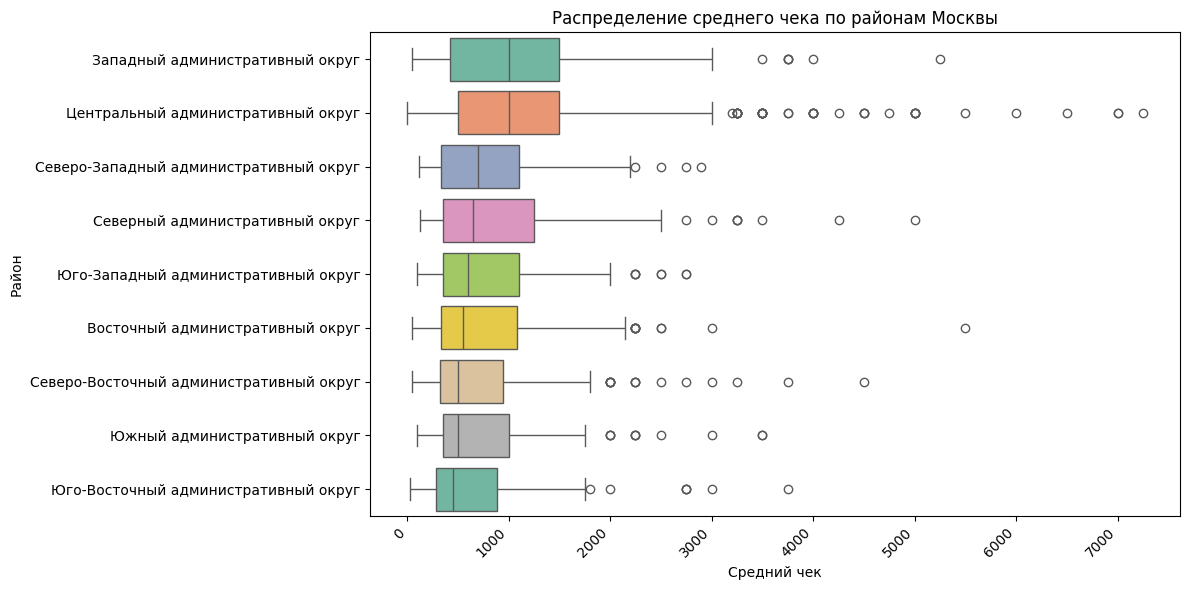

In [68]:
plt.figure(figsize=(12, 6))

filtered = rest_df[rest_df['middle_avg_bill'] <= 8000]

sorted_median = filtered.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False).index.tolist()

sns.boxplot(
    data=filtered,
    x='middle_avg_bill',
    y='district',
    palette='Set2',
    order=sorted_median
)

plt.xticks(rotation=45, ha='right')  
plt.title('Распределение среднего чека по районам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Район')
plt.tight_layout()
plt.show()

 В большинстве административных округов Москвы медианный средний чек находится в диапазоне 700–1000 рублей. Самые низкие показатели (около 700–750 рублей) фиксируются в Южном, Юго-Восточном и Юго-Западном округах.

 Центральный административный округ заметно выделяется — медиана здесь самая высокая (около 1200 рублей).

 Во всех районах есть заведения, которые сильно выбиваются из общей массы. Это указывает на наличие премиальных или элитных заведений в каждом округе, но именно в ЦАО их концентрация и ценовой потолок максимальны.

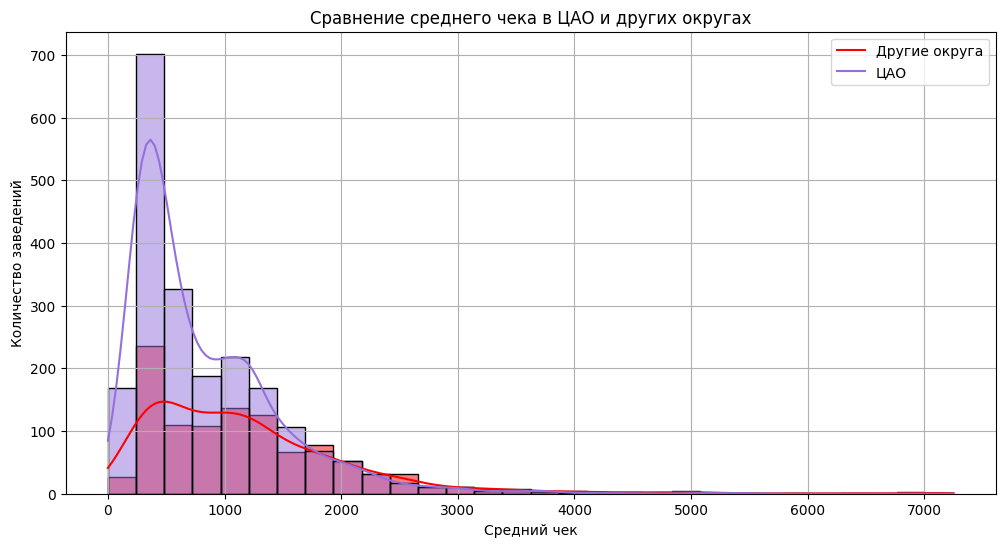

In [69]:
plt.figure(figsize=(12, 6))

rest_df['is_center'] = rest_df['district'] == 'Центральный административный округ'

sns.histplot(
    data=rest_df[rest_df['middle_avg_bill'] <= 8000],
    x='middle_avg_bill',
    bins=30,
    kde=True,
    alpha=0.5,
    palette=['mediumpurple', 'red'],
    hue='is_center'
)

plt.title('Сравнение среднего чека в ЦАО и других округах')
plt.xlabel('Средний чек')
plt.ylabel('Количество заведений')
plt.legend(['Другие округа', 'ЦАО'])
plt.grid()
plt.show()

Распределение среднего чека в ЦАО имеет ярко выраженный пик в диапазоне 250–500 рублей, что говорит о значительном преобладании недорогих заведений в центре города.

В других округах ситуация иная: средний чек более плавно распределяется от 250 до 1500 и далее.

Можно сказать, что в отличие от ЦАО, ценовое распределенение округов более равномерно, и сама цена в среднем соответсвенно выше.

Построим столбчатый график, где для каждой категории будет средняя и мединная цена, чтобы сравнить цены внутри округа и округа между собой

In [70]:
# Создадим дф с фильтром от выбросов 
filtered_2 = rest_df[rest_df['middle_avg_bill'] <= 3000]

# Создадим дф, где для каждого района, будет средняя и медианная цена
agg_median_avg = filtered_2.groupby('district').agg(avg_price=('middle_avg_bill', 'mean'),
                                                    median_price=('middle_avg_bill', 'median')).reset_index()

#Отсортируем датафрейм
agg_median_avg = agg_median_avg.sort_values(by=['avg_price', 'median_price'], ascending=False)

agg_median_avg

,district,avg_price,median_price
5,Центральный административный округ,1071.814453,1000.0
1,Западный административный округ,994.291687,925.0
2,Северный административный округ,842.234924,650.0
4,Северо-Западный административный округ,822.226135,700.0
7,Юго-Западный административный округ,792.565979,600.0
0,Восточный административный округ,766.914734,550.0
8,Южный административный округ,707.400330,500.0
3,Северо-Восточный административный округ,685.238281,500.0
6,Юго-Восточный административный округ,638.062195,450.0


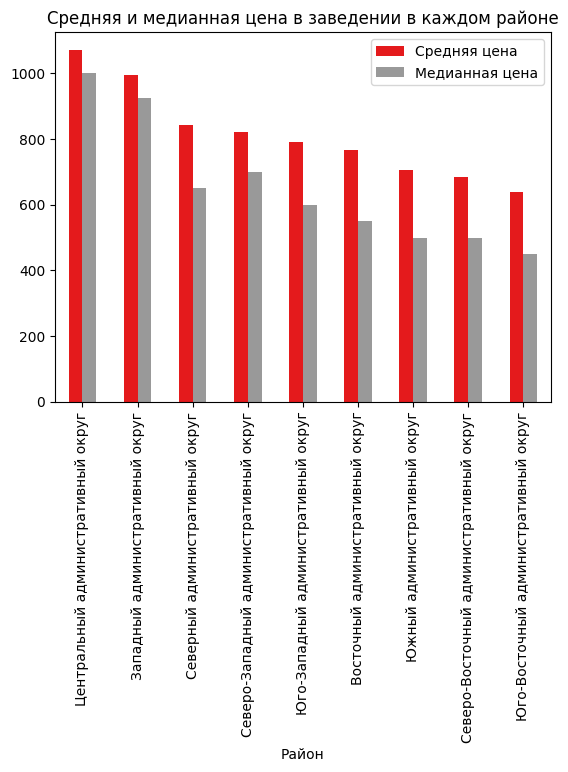

In [71]:
agg_median_avg.plot(
    kind='bar',
    x='district',
    y=['avg_price', 'median_price'],
    xlabel='Район',
    colormap='Set1'
)

plt.title('Средняя и медианная цена в заведении в каждом районе')
plt.legend(['Средняя цена', 'Медианная цена'])
plt.show()

Средняя цена отличается от медианной в каждом районе, так как есть выбросы. 

Самым дорогим районом по ценам по прежнему является **ЦАО** - медианная цена **1000 рублей**.

В спальных районах - цены меньше и варьируются от 450 до 925 по медиане

Самым недорогим по цене райном является **ЮВАО** - медианная цена **450 рублей**

## 4. Итоговый вывод и рекомендации

### Общий обзор проделанной работы 

Проведён полный EDA заведений общественного питания Москвы: объединены два датасета, выполнена предобработка (оптимизация типов, обработка пропусков, извлечение числовых значений среднего чека, удаление дубликатов), исследованы категории, районы, сетевость, вместимость, рейтинги, популярные сети и ценовые характеристики с визуализацией.

### Ответы на исследовательские вопросы, или главные выводы.

**Категории и районы**: Доминируют кафе, рестораны и кофейни (≈70%). ЦАО лидирует по количеству заведений (>2200), внутри него чаще встречаются рестораны и кофейни.

**Сетевость и вместимость**: Несетевые заведения — 62%. Среди сетей лидируют булочные (61%), пиццерии и кофейни (~50%). Типичная вместимость — 50–86 мест, распределение правостороннее, выбросы (>300 мест) — есть предположение, что это фудкорты и банкетные залы, которые априори должны вмещать большое кол-во мест.

**Рейтинг и факторы**: Средний рейтинг 4.2–4.4, значимых различий по категориям и районам нет. Слабая положительная корреляция с ценой (0.26) и круглосуточной работой (0.25).

**Популярные сети**: Топ-3 — «Шоколадница» (120 точек кофейни), «Домино's Пицца» (76 точек пиццерии), «Додо Пицца» (74 точек пиццерии). Высший рейтинг у «Буханки» (4.40) и «Кулинарной лавки братьев Караваевых» (4.39).

**Средний чек**: В ЦАО медиана выше (≈1200 руб.), чем в других округах (700–1000 руб.). В центре Москвы преобладают недорогие заведения (пик 250–500 руб.), в остальных округах цены распределены равномернее 250 - 1500.

### Рекомендации на основе анализа данных

**Формат заведения**: кофейня, булочная или пиццерия – их мало, высокий рейтинг (4.27–4.30) + проще сделать сеть.
Бар/паб – альтернатива с самым высоким рейтингом (4.39), но сложнее как сеть.

**Локация**: избегать ЦАО (перенасыщен). Предпочтительны САО, СЗАО, ЮАО – ниже конкуренция, средний чек 700–1000 руб, топ-3 района по рейтингу заведений.

**Цены**: оптимальный чек 800–1000 руб. (для спальных районов). Цена слабо влияет на рейтинг. 
Влияющим фактором будет указание цен на сайте или в приложениях, так как это положительно влияет на рейтинг

**Режим**: Некруглосуточные заведения оцениваются выше.

**Вместимость**: 50–70 мест.

**Итог**: Хорошим вариантом будет открыть кофейню/булочную/бар в САО, СЗАО, ЮАО со средним чеком 800–1000 руб., 50–70 мест